# Cotizacion de Seguro de Auto con Tarificacion AMIS

Este cuaderno construye una cotizacion completa de seguro de automovil usando las tablas de referencia de la AMIS (Asociacion Mexicana de Instituciones de Seguros). Se exploran los factores de tarificacion, el impacto de la zona de riesgo y antiguedad del vehiculo, el sistema Bonus-Malus, y el modelo colectivo de perdidas para estimar la prima pura y medidas de riesgo (VaR, TVaR).

**Estructura de la tarificacion**:
- Tasas base por millar de valor asegurado, diferenciadas por grupo de vehiculo y cobertura.
- Factores multiplicativos de zona, edad del conductor y deducible.
- Depreciacion del vehiculo por antiguedad.
- Ajuste Bonus-Malus segun historial de siniestros.

In [1]:
import sys
sys.path.insert(0, "../src")

from decimal import Decimal

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from suite_actuarial.danos import (
    SeguroAuto,
    ModeloColectivo,
    CalculadoraBonusMalus,
    FactorCredibilidad,
    Cobertura,
)
from suite_actuarial.danos.tablas_amis import (
    ZONAS_RIESGO,
    GRUPOS_VEHICULO,
    DEPRECIACION_VEHICULO,
)

print("Modulos cargados correctamente.")

Modulos cargados correctamente.


## Paso 1: Configurar vehiculo y conductor

Cotizaremos un **SUV mediano** con valor de $450,000 MXN, 3 anos de antiguedad, en la zona **CDMX Norte** (zona de alto riesgo), con un conductor de 40 anos y deducible del 5%.

Primero, revisemos los tipos de vehiculo y zonas disponibles.

In [2]:
# Tipos de vehiculo y su grupo de riesgo
print("GRUPOS DE VEHICULO (1=menor riesgo, 10=mayor riesgo)")
print("-" * 45)
for tipo, grupo in sorted(GRUPOS_VEHICULO.items(), key=lambda x: x[1]):
    print(f"  {tipo:20s}  Grupo {grupo}")

print()

# Zonas de riesgo (top 5 mas caras y top 5 mas baratas)
zonas_ordenadas = sorted(ZONAS_RIESGO.items(), key=lambda x: x[1], reverse=True)
print("ZONAS DE RIESGO (factor multiplicativo)")
print("-" * 45)
print("  Top 5 mas caras:")
for z, f in zonas_ordenadas[:5]:
    print(f"    {z:25s}  {f}")
print("  Top 5 mas baratas:")
for z, f in zonas_ordenadas[-5:]:
    print(f"    {z:25s}  {f}")

print()
print("COBERTURAS DISPONIBLES")
print("-" * 45)
for cob in Cobertura:
    print(f"  {cob.value}")

GRUPOS DE VEHICULO (1=menor riesgo, 10=mayor riesgo)
---------------------------------------------
  sedan_compacto        Grupo 1
  motocicleta           Grupo 2
  sedan_mediano         Grupo 3
  suv_compacto          Grupo 4
  pickup                Grupo 4
  suv_mediano           Grupo 5
  sedan_lujo            Grupo 6
  electrico             Grupo 7
  suv_lujo              Grupo 8
  deportivo             Grupo 9

ZONAS DE RIESGO (factor multiplicativo)
---------------------------------------------
  Top 5 mas caras:
    edo_mex_ecatepec           1.50
    cdmx_norte                 1.40
    edo_mex_tlalnepantla       1.40
    cdmx_oriente               1.35
    edo_mex_naucalpan          1.35
  Top 5 mas baratas:
    queretaro                  0.90
    resto_pais                 0.90
    aguascalientes             0.88
    merida                     0.85
    oaxaca                     0.80

COBERTURAS DISPONIBLES
---------------------------------------------
  danos_materiales
  rob

In [3]:
# Crear instancia de SeguroAuto
seguro = SeguroAuto(
    valor_vehiculo=Decimal("450000"),
    tipo_vehiculo="suv_mediano",
    antiguedad_anos=3,
    zona="cdmx_norte",
    edad_conductor=40,
    deducible_pct=Decimal("0.05"),
)

print(f"Vehiculo:          {seguro.tipo_vehiculo} (grupo {seguro.grupo})")
print(f"Valor original:    ${float(seguro.valor_vehiculo):>12,.2f}")
print(f"Depreciacion:      {float(seguro.factor_depreciacion)*100:.0f}%")
print(f"Valor asegurado:   ${float(seguro.valor_asegurado):>12,.2f}")
print(f"Zona:              {seguro.zona} (factor {seguro.factor_zona})")
print(f"Edad conductor:    {seguro.edad_conductor} ({seguro.rango_edad}, factor {seguro.factor_edad})")
print(f"Deducible:         {float(seguro.deducible_pct)*100:.0f}% (factor {seguro.factor_deducible})")

Vehiculo:          suv_mediano (grupo 5)
Valor original:    $  450,000.00
Depreciacion:      62%
Valor asegurado:   $  279,000.00
Zona:              cdmx_norte (factor 1.40)
Edad conductor:    40 (36-50, factor 0.95)
Deducible:         5% (factor 1.00)


## Paso 2: Generar cotizacion

La cotizacion desglosa la prima por cada cobertura, aplica todos los factores y muestra el total.

In [4]:
# Generar cotizacion completa
cotizacion = seguro.generar_cotizacion()

# Desglose por cobertura
df_cob = pd.DataFrame([
    {"Cobertura": k, "Prima anual ($)": f"${float(v):,.2f}"}
    for k, v in cotizacion["coberturas"].items()
])
print("DESGLOSE POR COBERTURA")
print(df_cob.to_string(index=False))
print()
print(f"Subtotal:            ${float(cotizacion['subtotal']):>10,.2f}")
print(f"Bonus-Malus:         nivel {cotizacion['bonus_malus']['nivel']} (factor {cotizacion['bonus_malus']['factor']})")
print(f"Prima total anual:   ${float(cotizacion['prima_total']):>10,.2f}")
print(f"Deducible en pesos:  ${float(cotizacion['deducible']['pesos']):>10,.2f}")

DESGLOSE POR COBERTURA
       Cobertura Prima anual ($)
danos_materiales      $14,471.73
      robo_total       $8,163.54
       rc_bienes       $2,523.28
     rc_personas       $2,077.99
  gastos_medicos       $1,113.21
 asistencia_vial         $630.82

Subtotal:            $ 28,980.57
Bonus-Malus:         nivel 0 (factor 1.00)
Prima total anual:   $ 28,980.57
Deducible en pesos:  $ 13,950.00


## Paso 3: Impacto de la zona de riesgo

La zona de circulacion es uno de los factores mas importantes en la tarificacion. Comparemos la prima total para el mismo vehiculo en 5 zonas diferentes.

            Zona  Factor  Prima total
edo_mex_ecatepec    1.50     31050.62
      cdmx_norte    1.40     28980.57
       monterrey    1.15     23805.46
       queretaro    0.90     18630.38
          oaxaca    0.80     16560.32


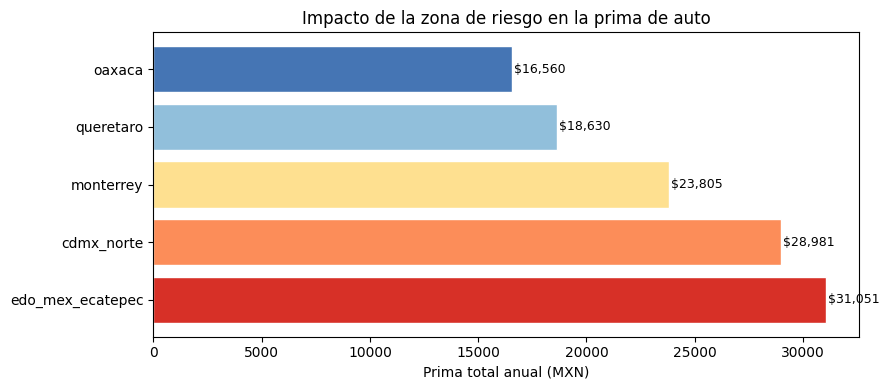

In [5]:
# Comparar 5 zonas
zonas_comparar = ["edo_mex_ecatepec", "cdmx_norte", "monterrey", "queretaro", "oaxaca"]
primas_zona = []

for zona in zonas_comparar:
    s = SeguroAuto(
        valor_vehiculo=Decimal("450000"),
        tipo_vehiculo="suv_mediano",
        antiguedad_anos=3,
        zona=zona,
        edad_conductor=40,
    )
    prima = float(s.calcular_prima_total())
    factor = float(ZONAS_RIESGO[zona])
    primas_zona.append({"Zona": zona, "Factor": factor, "Prima total": prima})

df_zonas = pd.DataFrame(primas_zona)
print(df_zonas.to_string(index=False))

# Grafica de barras
fig, ax = plt.subplots(figsize=(9, 4))
colores = ["#d73027", "#fc8d59", "#fee090", "#91bfdb", "#4575b4"]
bars = ax.barh(df_zonas["Zona"], df_zonas["Prima total"], color=colores, edgecolor="white")
ax.set_xlabel("Prima total anual (MXN)")
ax.set_title("Impacto de la zona de riesgo en la prima de auto")
for bar, val in zip(bars, df_zonas["Prima total"]):
    ax.text(val + 100, bar.get_y() + bar.get_height()/2, f"${val:,.0f}", va="center", fontsize=9)
plt.tight_layout()
plt.show()

## Paso 4: Impacto de la antiguedad del vehiculo

La depreciacion reduce el valor asegurado y, por lo tanto, la prima. Veamos como evoluciona la prima total para vehiculos de 0 a 10 anos de antiguedad.

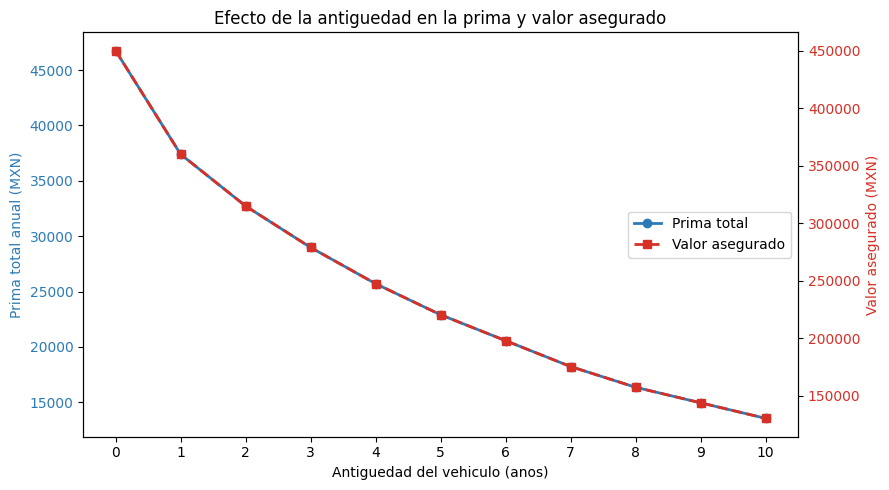

Tabla de depreciacion
--------------------------------------------------
  Ano  0:   100% del valor -> $  450,000.00 asegurado -> Prima $ 46,742.85
  Ano  1:    80% del valor -> $  360,000.00 asegurado -> Prima $ 37,394.28
  Ano  2:    70% del valor -> $  315,000.00 asegurado -> Prima $ 32,720.00
  Ano  3:    62% del valor -> $  279,000.00 asegurado -> Prima $ 28,980.57
  Ano  4:    55% del valor -> $  247,500.00 asegurado -> Prima $ 25,708.58
  Ano  5:    49% del valor -> $  220,500.00 asegurado -> Prima $ 22,904.00
  Ano  6:    44% del valor -> $  198,000.00 asegurado -> Prima $ 20,566.85
  Ano  7:    39% del valor -> $  175,500.00 asegurado -> Prima $ 18,229.72
  Ano  8:    35% del valor -> $  157,500.00 asegurado -> Prima $ 16,360.01
  Ano  9:    32% del valor -> $  144,000.00 asegurado -> Prima $ 14,957.71
  Ano 10:    29% del valor -> $  130,500.00 asegurado -> Prima $ 13,555.43


In [6]:
# Prima vs antiguedad (0-10 anos)
antiguedades = list(range(11))
primas_ant = []
valores_aseg = []

for ant in antiguedades:
    s = SeguroAuto(
        valor_vehiculo=Decimal("450000"),
        tipo_vehiculo="suv_mediano",
        antiguedad_anos=ant,
        zona="cdmx_norte",
        edad_conductor=40,
    )
    primas_ant.append(float(s.calcular_prima_total()))
    valores_aseg.append(float(s.valor_asegurado))

fig, ax1 = plt.subplots(figsize=(9, 5))
color1 = "#2c7bb6"
color2 = "#d73027"

ax1.plot(antiguedades, primas_ant, "o-", color=color1, linewidth=2, label="Prima total")
ax1.set_xlabel("Antiguedad del vehiculo (anos)")
ax1.set_ylabel("Prima total anual (MXN)", color=color1)
ax1.tick_params(axis="y", labelcolor=color1)

ax2 = ax1.twinx()
ax2.plot(antiguedades, valores_aseg, "s--", color=color2, linewidth=2, label="Valor asegurado")
ax2.set_ylabel("Valor asegurado (MXN)", color=color2)
ax2.tick_params(axis="y", labelcolor=color2)

ax1.set_title("Efecto de la antiguedad en la prima y valor asegurado")
ax1.set_xticks(antiguedades)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="center right")

plt.tight_layout()
plt.show()

# Tabla de depreciacion
print("Tabla de depreciacion")
print("-" * 50)
for ant in antiguedades:
    dep = float(DEPRECIACION_VEHICULO[min(ant, 10)])
    print(f"  Ano {ant:>2}: {dep*100:5.0f}% del valor -> ${valores_aseg[ant]:>12,.2f} asegurado -> Prima ${primas_ant[ant]:>10,.2f}")

## Paso 5: Sistema Bonus-Malus

El sistema Bonus-Malus premia a los conductores sin siniestros (descuento acumulativo) y penaliza a quienes reportan siniestros (recargo). La escala mexicana tipica va de nivel -5 (30% de descuento) a nivel +3 (50% de recargo).

Simulemos una trayectoria de 7 anos: 3 anos sin siniestros, luego 1 siniestro, y despues 3 anos de recuperacion.

ESCALA BONUS-MALUS COMPLETA
----------------------------------------
  Nivel  -5: factor 0.70 (descuento)
  Nivel  -4: factor 0.75 (descuento)
  Nivel  -3: factor 0.80 (descuento)
  Nivel  -2: factor 0.85 (descuento)
  Nivel  -1: factor 0.90 (descuento)
  Nivel   0: factor 1.00 (BASE)
  Nivel   1: factor 1.15 (recargo)
  Nivel   2: factor 1.30 (recargo)
  Nivel   3: factor 1.50 (recargo)

TRAYECTORIA DE 7 ANOS
----------------------------------------------------------------------
 ano  siniestros  nivel_previo  nivel_nuevo factor
   1           0             0           -1   0.90
   2           0            -1           -2   0.85
   3           0            -2           -3   0.80
   4           1            -3           -1   0.90
   5           0            -1           -2   0.85
   6           0            -2           -3   0.80
   7           0            -3           -4   0.75


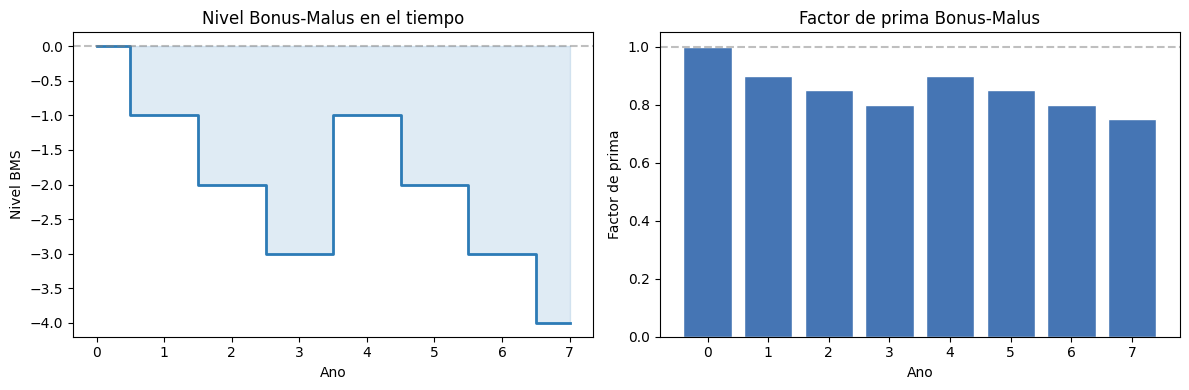

In [7]:
# Trayectoria Bonus-Malus: 3 anos limpios, 1 siniestro, 3 anos recuperacion
bms = CalculadoraBonusMalus(nivel_actual=0)
historial = [0, 0, 0, 1, 0, 0, 0]

trayectoria = bms.historial_completo(historial)

# Mostrar tabla
print("ESCALA BONUS-MALUS COMPLETA")
print("-" * 40)
for nivel, factor in sorted(CalculadoraBonusMalus.NIVELES.items()):
    desc = "BASE" if nivel == 0 else ("descuento" if nivel < 0 else "recargo")
    print(f"  Nivel {nivel:>3}: factor {factor} ({desc})")

print()
print("TRAYECTORIA DE 7 ANOS")
print("-" * 70)
df_bms = pd.DataFrame(trayectoria)
df_bms["factor"] = df_bms["factor"].apply(lambda x: f"{float(x):.2f}")
print(df_bms.to_string(index=False))

# Grafica de la trayectoria
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

niveles = [0] + [t["nivel_nuevo"] for t in trayectoria]
factores_bms = [1.0] + [float(t["factor"]) for t in trayectoria]
anos = list(range(len(niveles)))

ax1.step(anos, niveles, where="mid", linewidth=2, color="#2c7bb6")
ax1.axhline(y=0, color="gray", linestyle="--", alpha=0.5)
ax1.fill_between(anos, niveles, 0, step="mid", alpha=0.15, color="#2c7bb6")
ax1.set_xlabel("Ano")
ax1.set_ylabel("Nivel BMS")
ax1.set_title("Nivel Bonus-Malus en el tiempo")
ax1.set_xticks(anos)

ax2.bar(anos, factores_bms, color=["#4575b4" if f <= 1.0 else "#d73027" for f in factores_bms], edgecolor="white")
ax2.axhline(y=1.0, color="gray", linestyle="--", alpha=0.5)
ax2.set_xlabel("Ano")
ax2.set_ylabel("Factor de prima")
ax2.set_title("Factor de prima Bonus-Malus")
ax2.set_xticks(anos)

plt.tight_layout()
plt.show()

## Paso 6: Modelo colectivo de perdidas

El modelo colectivo S = X1 + X2 + ... + XN modela las perdidas agregadas de un portafolio, donde N (frecuencia) sigue una distribucion Poisson y Xi (severidad) sigue una distribucion lognormal. Esto permite calcular la prima pura, el VaR y el TVaR via simulacion Monte Carlo.

In [8]:
# Modelo colectivo: Poisson(lambda=3.5) + Lognormal(mu=10, sigma=1.2)
# Esto modela un portafolio con ~3.5 siniestros anuales por poliza
# y severidad media de exp(10 + 1.2^2/2) ~ $48,000 MXN
modelo = ModeloColectivo(
    dist_frecuencia="poisson",
    params_frecuencia={"lambda_": 3.5},
    dist_severidad="lognormal",
    params_severidad={"mu": 10.0, "sigma": 1.2},
)

# Momentos analiticos
prima_pura = modelo.prima_pura()
varianza = modelo.varianza_agregada()
desv_est = modelo.desviacion_estandar()

print("MODELO COLECTIVO DE PERDIDAS")
print("=" * 50)
print(f"  Frecuencia:            Poisson(lambda=3.5)")
print(f"  Severidad:             Lognormal(mu=10, sigma=1.2)")
print(f"  Prima pura E[S]:       ${float(prima_pura):>14,.2f}")
print(f"  Varianza Var[S]:       ${float(varianza):>14,.2f}")
print(f"  Desviacion estandar:   ${float(desv_est):>14,.2f}")
print()

# Simulacion y medidas de riesgo
stats = modelo.estadisticas(n_simulaciones=50_000, seed=42)
print("MEDIDAS DE RIESGO (50,000 simulaciones)")
print("-" * 50)
print(f"  VaR 95%:               ${float(stats['var_95']):>14,.2f}")
print(f"  TVaR 95%:              ${float(stats['tvar_95']):>14,.2f}")
print(f"  VaR 99%:               ${float(stats['var_99']):>14,.2f}")
print(f"  TVaR 99%:              ${float(stats['tvar_99']):>14,.2f}")
print(f"  Asimetria:             {float(stats['asimetria']):>14.4f}")
print(f"  Minimo:                ${float(stats['minimo']):>14,.2f}")
print(f"  Maximo:                ${float(stats['maximo']):>14,.2f}")

MODELO COLECTIVO DE PERDIDAS
  Frecuencia:            Poisson(lambda=3.5)
  Severidad:             Lognormal(mu=10, sigma=1.2)
  Prima pura E[S]:       $    158,381.66
  Varianza Var[S]:       $30,250,028,648.94
  Desviacion estandar:   $    173,925.35

MEDIDAS DE RIESGO (50,000 simulaciones)
--------------------------------------------------
  VaR 95%:               $    464,314.53
  TVaR 95%:              $    692,488.17
  VaR 99%:               $    806,285.88
  TVaR 99%:              $  1,140,798.01
  Asimetria:                     4.5618
  Minimo:                $          0.00
  Maximo:                $  6,702,028.55


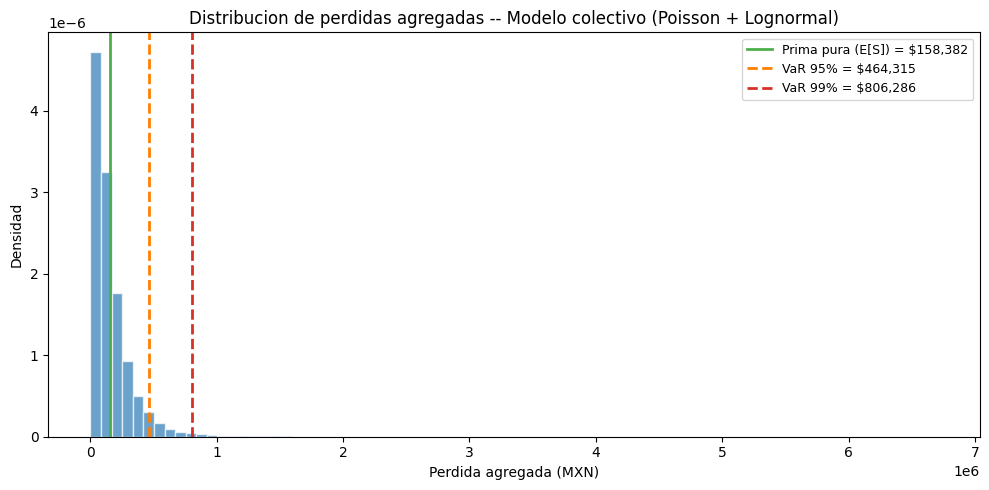

In [9]:
# Histograma de perdidas simuladas
perdidas = modelo.simular_perdidas(n_simulaciones=50_000, seed=42)

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(perdidas, bins=80, density=True, color="#2c7bb6", alpha=0.7, edgecolor="white")

# Lineas de referencia
var95 = float(stats["var_95"])
var99 = float(stats["var_99"])
media = float(prima_pura)

ax.axvline(media, color="#4daf4a", linewidth=2, linestyle="-", label=f"Prima pura (E[S]) = ${media:,.0f}")
ax.axvline(var95, color="#ff7f00", linewidth=2, linestyle="--", label=f"VaR 95% = ${var95:,.0f}")
ax.axvline(var99, color="#d73027", linewidth=2, linestyle="--", label=f"VaR 99% = ${var99:,.0f}")

ax.set_xlabel("Perdida agregada (MXN)")
ax.set_ylabel("Densidad")
ax.set_title("Distribucion de perdidas agregadas -- Modelo colectivo (Poisson + Lognormal)")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## Conclusiones

1. **Tarificacion por factores**: La prima de auto se construye multiplicando tasas base por factores de zona, edad del conductor, deducible y depreciacion. Este esquema multiplicativo permite ajustar rapidamente la tarifa a cada perfil de riesgo.

2. **Zona de riesgo**: Es el factor de mayor impacto. La diferencia entre Ecatepec (factor 1.50) y Oaxaca (factor 0.80) puede casi duplicar la prima para el mismo vehiculo.

3. **Depreciacion**: Un vehiculo pierde ~70% de su valor asegurado en 10 anos, reduciendo proporcionalmente la prima de coberturas propias (danos materiales, robo).

4. **Bonus-Malus**: Un solo siniestro sube el nivel 2 escalones (+15-30% de recargo). Recuperar el descuento maximo (-30%) requiere 5 anos consecutivos sin siniestros.

5. **Modelo colectivo**: La distribucion de perdidas agregadas es asimetrica a la derecha (cola pesada), lo que justifica el uso del TVaR sobre el VaR para establecer reservas y capital de solvencia.